# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

2.  Specify the outcome variable and how it is measured.

3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?

4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?

5.  State the sets of null and alternative hypotheses for this experiment.



6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

The exploratory analysis included summary statistics and boxplots comparing sprint times across blade types and athletes. The mean sprint times for Blade Type A and Blade Type B appear to be relatively similar, and the boxplot comparing blade types does not show a strong separation between the two groups.

However, when examining sprint times by athlete, there is clear variability across individuals. Some athletes consistently have faster or slower times regardless of blade type, indicating that athlete-specific differences contribute substantially to overall variation.

Overall, the exploratory results do not show strong visual evidence of a difference between the blade types. Therefore, the analysis appears to support the null hypothesis more strongly, although a formal statistical test is needed to confirm this conclusion.

📥 Cloning repo from https://github.com/garrettspringsted/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Nested and Split Plot Designs/STAT-7220-Applied-Experimental-Design/Experiments with Random Factors/STAT-7220-Applied-Experimental-Design/Experiments with Random Factors/STAT-7220-Applied-Experimental-Design/Experiments with Random Factors/STAT-7220-Applied-Experimental-Design/Experiments with Random Factors/STAT-7220-Applied-Experimental-Design/Experiments with Random Factors/STAT-7220-Applied-Experimental-Design/Experiments with Random Factors/STAT-7220-Applied-Experimental-Design/Experiments with Random Factors/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/garrettspringsted/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Nested and Split Plot Designs/STAT-7220-Applied-Experimental-Design/Experiments with Random Fac

/tmp/ipykernel_4245/4260373406.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Blade_Type',y='Sprint_Time',data=blades, palette='Set3')


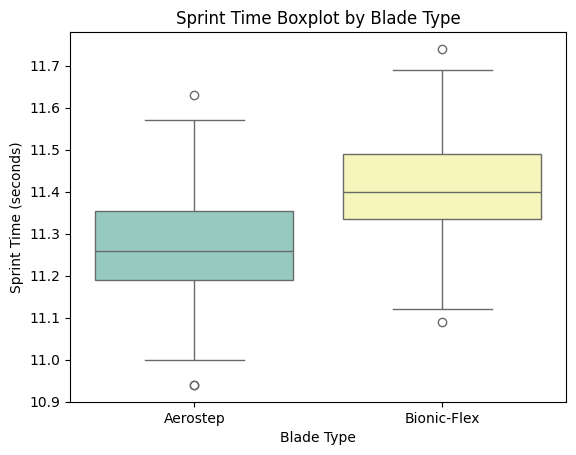

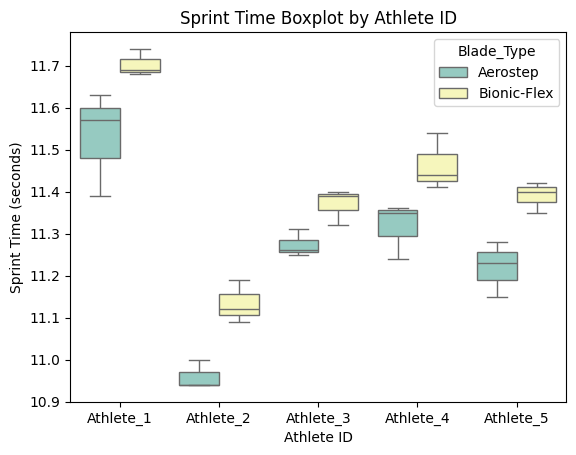

Index(['Athlete_ID', 'Blade_Type', 'Trial', 'Sprint_Time'], dtype='object')


In [22]:
from numpy._core.fromnumeric import mean
import os
# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "garrettspringsted"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Experiments with Random Factors"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")


## Import Libraries ##
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
import seaborn as sns

blades = pd.read_excel('STAT Paralympic_Blade_Experiment.xlsx')

print(blades.head())
print(blades.info())

blades_stats= blades.groupby('Blade_Type')['Sprint_Time'].agg(['mean','std']).reset_index()
print(blades_stats)

athlete_blade_stats=blades.groupby(['Athlete_ID','Blade_Type'])['Sprint_Time'].agg(['mean','std']).reset_index()
print(athlete_blade_stats)

sns.boxplot(x='Blade_Type',y='Sprint_Time',data=blades, palette='Set3')
plt.title('Sprint Time Boxplot by Blade Type')
plt.xlabel('Blade Type')
plt.ylabel('Sprint Time (seconds)')
plt.show()

sns.boxplot(x='Athlete_ID',y='Sprint_Time', hue='Blade_Type', data=blades, palette='Set3')
plt.title('Sprint Time Boxplot by Athlete ID')
plt.xlabel('Athlete ID')
plt.ylabel('Sprint Time (seconds)')
plt.show()

print(blades.columns)

7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

A mixed effects model was fit with Sprint Time as the response variable. Blade Type was included as a fixed effect and Athlete ID was included as a random effect to account for variability between athletes.

The results show that Blade Type is a statistically significant predictor of sprint time (p < 0.001). On average, sprint times using the Bionic-Flex blade are approximately 0.152 seconds higher compared to the Aerostep blade, holding athlete differences constant.

Additionally, the estimated variance for the random effect (Athlete ID) is 0.041, indicating that there is meaningful variability in sprint times across athletes that is accounted for in the model.

In [23]:
from ast import mod
from statsmodels.formula.api import mixedlm

mod = mixedlm("Sprint_Time ~ Blade_Type", data=blades, groups="Athlete_ID")
res = mod.fit()
print(res.summary())

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Sprint_Time
No. Observations:     30          Method:                 REML       
No. Groups:           5           Scale:                  0.0034     
Min. group size:      6           Log-Likelihood:         28.3941    
Max. group size:      6           Converged:              Yes        
Mean group size:      6.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.260    0.092 122.543 0.000 11.080 11.440
Blade_Type[T.Bionic-Flex]  0.152    0.021   7.095 0.000  0.110  0.194
Athlete_ID Var             0.041    0.542                            



8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

In [ ]:
## Question 8 Code ##

9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?

In [ ]:
## Question 9 Code ##

10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?

In [ ]:
## Question 10 Code ##

11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.